100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.32MB/s]


Epoch [1/10] Loss D: 0.7341 Loss G: 3.5568
Epoch [2/10] Loss D: 0.1025 Loss G: 3.8656
Epoch [3/10] Loss D: 0.2692 Loss G: 2.4331
Epoch [4/10] Loss D: 0.2517 Loss G: 4.5171
Epoch [5/10] Loss D: 0.0779 Loss G: 4.8763
Epoch [6/10] Loss D: 0.1352 Loss G: 6.0111
Epoch [7/10] Loss D: 0.1980 Loss G: 6.0031
Epoch [8/10] Loss D: 0.2640 Loss G: 5.9645
Epoch [9/10] Loss D: 0.4886 Loss G: 2.1232
Epoch [10/10] Loss D: 0.3156 Loss G: 5.1973


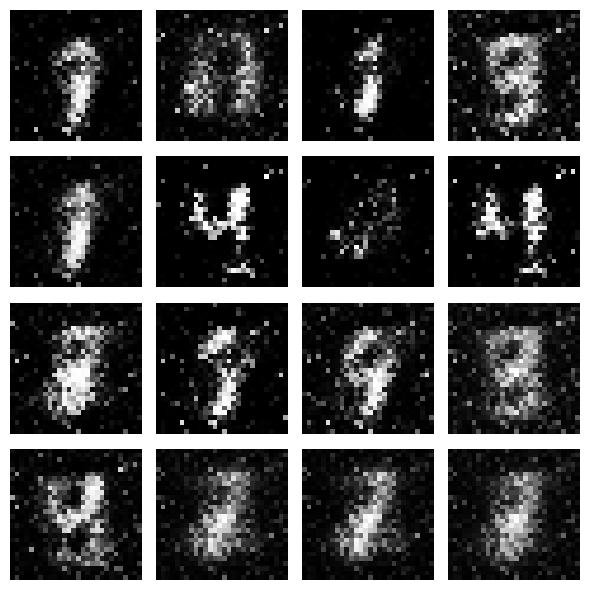

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -------------------------------
# 1. Device
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 2. Load MNIST Dataset
# -------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# -------------------------------
# 3. Generator
# -------------------------------
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# -------------------------------
# 4. Discriminator
# -------------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Create models
G = Generator().to(device)
D = Discriminator().to(device)

# -------------------------------
# 5. Loss and Optimizers
# -------------------------------
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

# -------------------------------
# 6. Training
# -------------------------------
epochs = 10

for epoch in range(epochs):

    for real_images, _ in dataloader:

        # Flatten image: 28x28 -> 784
        real_images = real_images.view(-1, 784).to(device)

        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # --------------------------------
        # Train Discriminator
        # --------------------------------

        # Real images
        real_output = D(real_images)
        loss_real = criterion(real_output, real_labels)

        # Fake images
        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G(noise)

        fake_output = D(fake_images.detach())
        loss_fake = criterion(fake_output, fake_labels)

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # --------------------------------
        # Train Generator
        # --------------------------------

        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G(noise)

        output = D(fake_images)

        # Generator wants discriminator to think
        # fake images are real
        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss D: {loss_D.item():.4f} "
        f"Loss G: {loss_G.item():.4f}"
    )

# -------------------------------
# 7. Generate Images
# -------------------------------
noise = torch.randn(16, 100).to(device)
generated_images = G(noise)

generated_images = generated_images.view(-1, 28, 28)
generated_images = generated_images.detach().cpu()

# -------------------------------
# 8. Display Generated Images
# -------------------------------
plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()